In [1]:
from partition_tree.sklearn.partition_tree import PartitionForestRegressor
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
# Blob make regression dataset import from sklearn
from sklearn.datasets import make_blobs


X, y = make_blobs(n_samples=1000, centers=3, n_features=2, random_state=42)
y = X[:, 1]
y = y - y.min()
y /= y.max()
X = X[:, 0].reshape(-1, 1)

/var/folders/_2/9y4tsvdd2n3gqjgd2zmlr1km0000gn/T/ipykernel_67246/1687421163.py:2: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  scatter = ax.scatter(X[:, 0], y, cmap='viridis', edgecolor='k')
/Users/felipeangelim/Workspace/partition_tree/partition_tree/.venv/lib/python3.12/site-packages/matplotlib/collections.py:1112: UserWarning: Collection without array used. Make sure to specify the values to be colormapped via the `c` argument.
  warnings.warn("Collection without array used. Make sure to "


Text(0.5, 1.0, 'Circles Dataset')

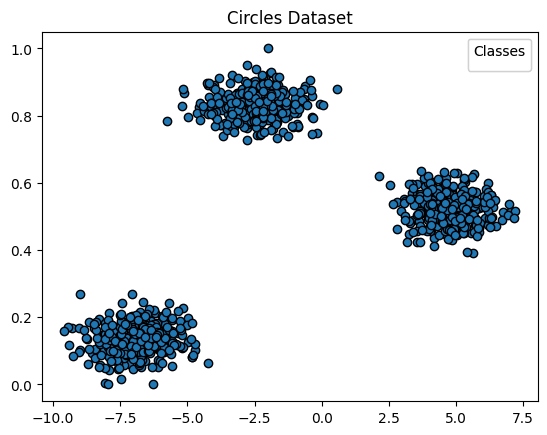

In [2]:
fig, ax = plt.subplots()
scatter = ax.scatter(X[:, 0], y, cmap='viridis', edgecolor='k')
legend1 = ax.legend(*scatter.legend_elements(), title="Classes")
ax.add_artist(legend1)
plt.title("Circles Dataset")

In [9]:
from partition_tree.skpro.partition_tree import PartitionTreeRegressor

tree = PartitionTreeRegressor(
    max_leaves=10,
    min_samples_xy=0,
    boundaries_expansion_factor=0.05,
    min_volume_fraction=0.2,
    min_samples_x=1,
    loss="balanced_log_loss",
)

tree.fit(X, y)

PartitionTreeRegressor(boundaries_expansion_factor=0.05,
                       loss='balanced_log_loss', max_leaves=10, min_samples_x=1,
                       min_samples_xy=0, min_volume_fraction=0.2)

In [10]:
tree.partition_tree_.get_nodes_info()

[{'node_index': 0,
  'is_leaf': False,
  'depth': 0,
  'parent': None,
  'left_child': 1,
  'right_child': 2,
  'w_xy': 1000.0,
  'w_x': 1000.0,
  'w_y': 1000.0,
  'conditional_density': 0.9523809523809526,
  'partitions': {'target_0': {'type': 'continuous',
    'low': -0.025000000000000022,
    'high': 1.025,
    'lower_closed': True,
    'upper_closed': True},
   '0': {'type': 'continuous',
    'low': -inf,
    'high': inf,
    'lower_closed': True,
    'upper_closed': True}}},
 {'node_index': 1,
  'is_leaf': False,
  'depth': 1,
  'parent': 0,
  'left_child': 3,
  'right_child': 4,
  'w_xy': 292.0,
  'w_x': 1000.0,
  'w_y': 292.0,
  'conditional_density': 0.292,
  'partitions': {'target_0': {'type': 'continuous',
    'low': -0.025000000000000022,
    'high': 0.1852402645188183,
    'lower_closed': True,
    'upper_closed': False},
   '0': {'type': 'continuous',
    'low': -inf,
    'high': inf,
    'lower_closed': True,
    'upper_closed': True}}},
 {'node_index': 2,
  'is_leaf': Fa

Saved → partition_tree_sequence.gif


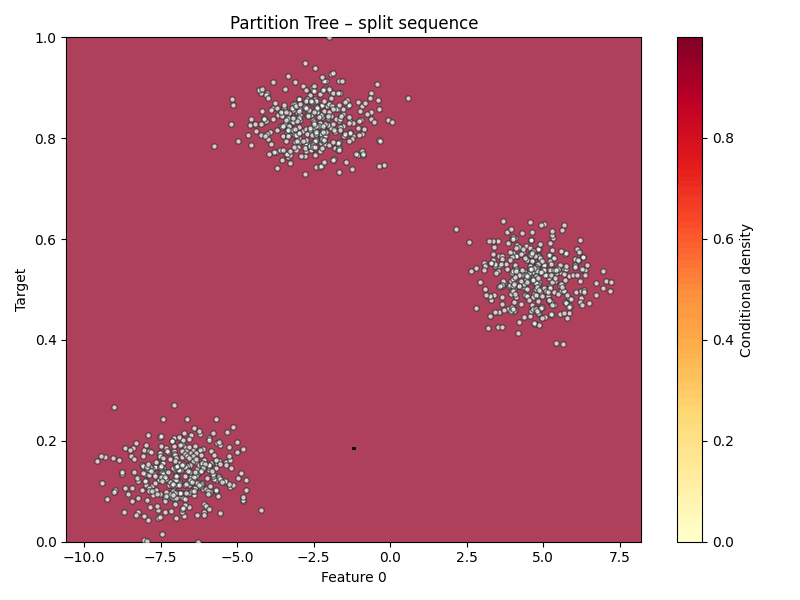

In [11]:
import matplotlib.patches as mpatches
import matplotlib.animation as animation
import matplotlib.colors as mcolors
from matplotlib.animation import PillowWriter
from IPython.display import Image
import numpy as np

# ── Data ────────────────────────────────────────────────────────────────────
nodes_info  = tree.partition_tree_.get_nodes_info()
nodes_by_idx = {n['node_index']: n for n in nodes_info}

x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
y_min, y_max = y.min(), y.max()

# Density colormap normalised over ALL nodes
all_densities = [n['conditional_density'] for n in nodes_info]
norm = mcolors.Normalize(vmin=min(all_densities), vmax=max(all_densities))
cmap = plt.cm.YlOrRd

# ── Helpers ─────────────────────────────────────────────────────────────────
def clip(v, lo, hi):
    if np.isinf(v):
        return hi if v > 0 else lo
    return v

def node_rect(node):
    """Return (x0, y0, w, h) for a node's partition box."""
    px = node['partitions']['0']
    py = node['partitions']['target_0']
    x0 = clip(px['low'],  x_min, x_max)
    x1 = clip(px['high'], x_min, x_max)
    y0 = clip(py['low'],  y_min, y_max)
    y1 = clip(py['high'], y_min, y_max)
    return x0, y0, x1 - x0, y1 - y0

def find_split(parent, left):
    """Return (dim, split_value) – the axis and position of the cut."""
    for dim in parent['partitions']:
        pp = parent['partitions'][dim]
        lp = left['partitions'][dim]
        # left child's 'high' shrinks when this dim is split
        ph, lh = pp['high'], lp['high']
        eq = (np.isinf(ph) and np.isinf(lh) and np.sign(ph) == np.sign(lh)) or \
             (not np.isinf(ph) and not np.isinf(lh) and abs(ph - lh) < 1e-9)
        if not eq:
            return dim, lp['high']
    return None, None

def split_line(parent, dim, val):
    """Return (x0,y0,x1,y1) for the split line clipped to the parent rect."""
    if dim == '0':            # vertical line
        perp = parent['partitions']['target_0']
        x0 = x1 = val
        y0 = clip(perp['low'],  y_min, y_max)
        y1 = clip(perp['high'], y_min, y_max)
    else:                     # horizontal line
        perp = parent['partitions']['0']
        y0 = y1 = val
        x0 = clip(perp['low'],  x_min, x_max)
        x1 = clip(perp['high'], x_min, x_max)
    return x0, y0, x1, y1

def ease(t):
    return t * t * (3 - 2 * t)

# ── Build split sequence (BFS order) ─────────────────────────────────────────
internal_nodes = sorted(
    [n for n in nodes_info if not n['is_leaf']],
    key=lambda n: (n['depth'], n['node_index'])
)

steps = []
active_set = {0}                         # node indices currently rendered
for node in internal_nodes:
    left  = nodes_by_idx[node['left_child']]
    right = nodes_by_idx[node['right_child']]
    dim, val = find_split(node, left)
    x0, y0, x1, y1 = split_line(node, dim, val)
    steps.append({
        'active_before': set(active_set),
        'split_node': node,
        'left':  left,
        'right': right,
        'line': (x0, y0, x1, y1),
        'dim':  dim,
    })
    active_set.discard(node['node_index'])
    active_set.add(left['node_index'])
    active_set.add(right['node_index'])
steps.append({'active_before': set(active_set), 'split_node': None})  # final hold

# ── Animation setup ─────────────────────────────────────────────────────────
DRAW   = 35   # frames to grow the split line
COLOR  = 20   # frames to hold with updated colour before next split
HOLD   = 40   # frames at end

fig, ax = plt.subplots(figsize=(8, 6))
ax.set_xlim(x_min, x_max)
ax.set_ylim(y_min, y_max)
ax.scatter(X[:, 0], y, c='white', edgecolor='#333', alpha=0.7, zorder=4, s=15)
ax.set_xlabel("Feature 0")
ax.set_ylabel("Target")
ax.set_title("Partition Tree – split sequence")
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
plt.colorbar(sm, ax=ax, label='Conditional density')
fig.tight_layout()

# One patch per node (we'll show/hide as needed)
patch_objs = {}
for node in nodes_info:
    x0, y0, w, h = node_rect(node)
    p = mpatches.Rectangle(
        (x0, y0), w, h,
        facecolor=cmap(norm(node['conditional_density'])),
        edgecolor='white', linewidth=0.8,
        alpha=0, zorder=1
    )
    ax.add_patch(p)
    patch_objs[node['node_index']] = p

# One growing line per split
line_objs = []
for step in steps[:-1]:
    x0, y0, x1, y1 = step['line']
    ln, = ax.plot([x0, x0], [y0, y0], color='black', lw=2, zorder=3)
    line_objs.append(ln)

def show_active(active_set):
    for nidx, patch in patch_objs.items():
        patch.set_alpha(0.75 if nidx in active_set else 0)

# Pre-compute per-frame state
frames_data = []
for si, step in enumerate(steps[:-1]):
    # Phase 1: grow line
    for f in range(DRAW):
        frames_data.append(('draw', si, f))
    # Phase 2: hold with new colours
    for f in range(COLOR):
        frames_data.append(('color', si, f))
# Final hold
for f in range(HOLD):
    frames_data.append(('hold', len(steps)-1, f))

def animate(frame_idx):
    phase, si, fi = frames_data[frame_idx]
    step = steps[si]

    if phase == 'draw':
        # Show active_before colours
        show_active(step['active_before'])
        # Grow line from midpoint outward
        t = ease((fi + 1) / DRAW)
        x0, y0, x1, y1 = step['line']
        mx, my = (x0 + x1) / 2, (y0 + y1) / 2
        line_objs[si].set_xdata([mx - (mx - x0) * t, mx + (x1 - mx) * t])
        line_objs[si].set_ydata([my - (my - y0) * t, my + (y1 - my) * t])

    elif phase == 'color':
        # Line complete, update to children colours
        active_after = (step['active_before'] - {step['split_node']['node_index']}) | \
                       {step['left']['node_index'], step['right']['node_index']}
        show_active(active_after)
        x0, y0, x1, y1 = step['line']
        line_objs[si].set_xdata([x0, x1])
        line_objs[si].set_ydata([y0, y1])

    else:  # hold
        show_active(steps[si]['active_before'])

    return list(patch_objs.values()) + line_objs

ani = animation.FuncAnimation(
    fig, animate,
    frames=len(frames_data),
    interval=1000 / 30,
    blit=True,
)

gif_path = "partition_tree_sequence.gif"
ani.save(gif_path, writer=PillowWriter(fps=30))
plt.close(fig)
print(f"Saved → {gif_path}")
Image(gif_path)


In [ ]:
``